In [133]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [48]:
df = pd.read_csv('data/cleaned.csv')
df.head()

,date,contest_num,word,n_reported,n_hard,try_1,try_2,try_3,try_4,try_5,try_6,try_x
0,2022-12-31,560,manly,20380,1899,0,2,17,37,29,12,2
1,2022-12-30,559,molar,21204,1973,0,4,21,38,26,9,1
2,2022-12-29,558,havoc,20001,1919,0,2,16,38,30,12,2
3,2022-12-28,557,impel,20160,1937,0,3,21,40,25,9,1
4,2022-12-27,556,condo,20879,2012,0,2,17,35,29,14,3


# 1. Hard mode ratio

In [50]:
df['hard/reported%'] = (df['n_hard'] / df['n_reported']) * 100

In [51]:
print(df.sort_values('hard/reported%', ascending=False).head())
print('-' * 50)
print(df.sort_values('hard/reported%', ascending=True).head())

           date  contest_num   word  n_reported  n_hard  try_1  try_2  try_3  \
60   2022-11-01          500  piney       27502    3667      0      1     14   
106  2022-09-16          454  parer       37309    4130      0      0      4   
69   2022-10-23          491  mummy       29279    3021      0      1      4   
77   2022-10-15          483  catch       30403    3123      0      7     18   
5    2022-12-26          555  judge       20011    2043      0      2      8   

     try_4  try_5  try_6  try_x  hard/reported%  
60      37     33     14      2       13.333576  
106     11     15     22     48       11.069715  
69      14     27     37     18       10.317975  
77      20     15     16     23       10.272013  
5       16     26     33     14       10.209385  
--------------------------------------------------
           date  contest_num   word  n_reported  n_hard  try_1  try_2  try_3  \
320  2022-02-13          239  robin      277471    3249      1      6     29   
357  202

**Conclusion**: In the most recent dates, the proportion of hard mode players has increased compared to earlier dates, while the absolute number of hard mode players has remained roughly the same. \
This indicates a change in the total number of players. Therefore, more recent dates are likely more relevant for predicting the data for ‘2023-03-01’.


# 2. Number of players over time

In [67]:
# ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

In [68]:
def plot_n_players(df, date_from='1900-01-01', date_to='2100-01-01'):
    df_filtered = df[df['date'].between(date_from, date_to)]

    df_filtered = df_filtered.sort_values('date')

    plt.figure(figsize=(20, 5))
    plt.plot(df_filtered['date'], df_filtered['n_reported'])

    plt.xlabel('Date')
    plt.ylabel('Reported Results')
    plt.title('Reported Results Over Time')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

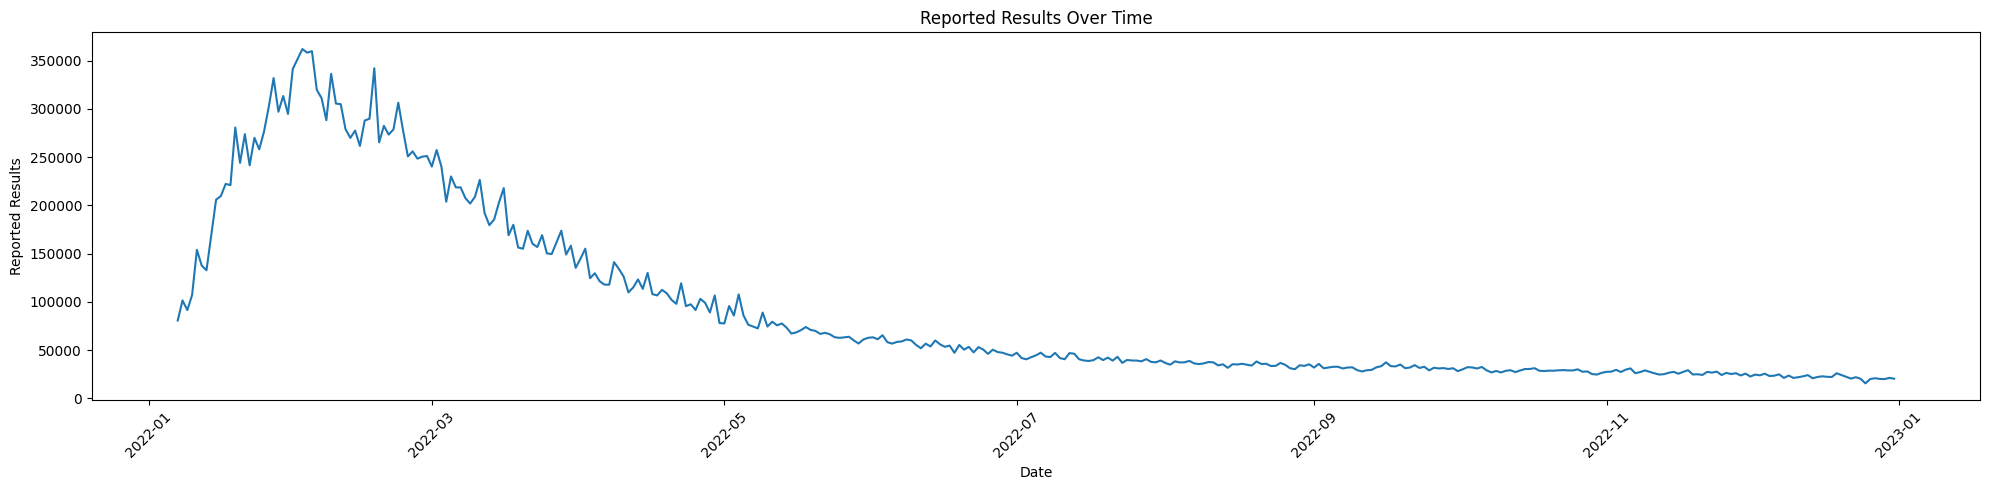

In [69]:
plot_n_players(df)

## Relevant data

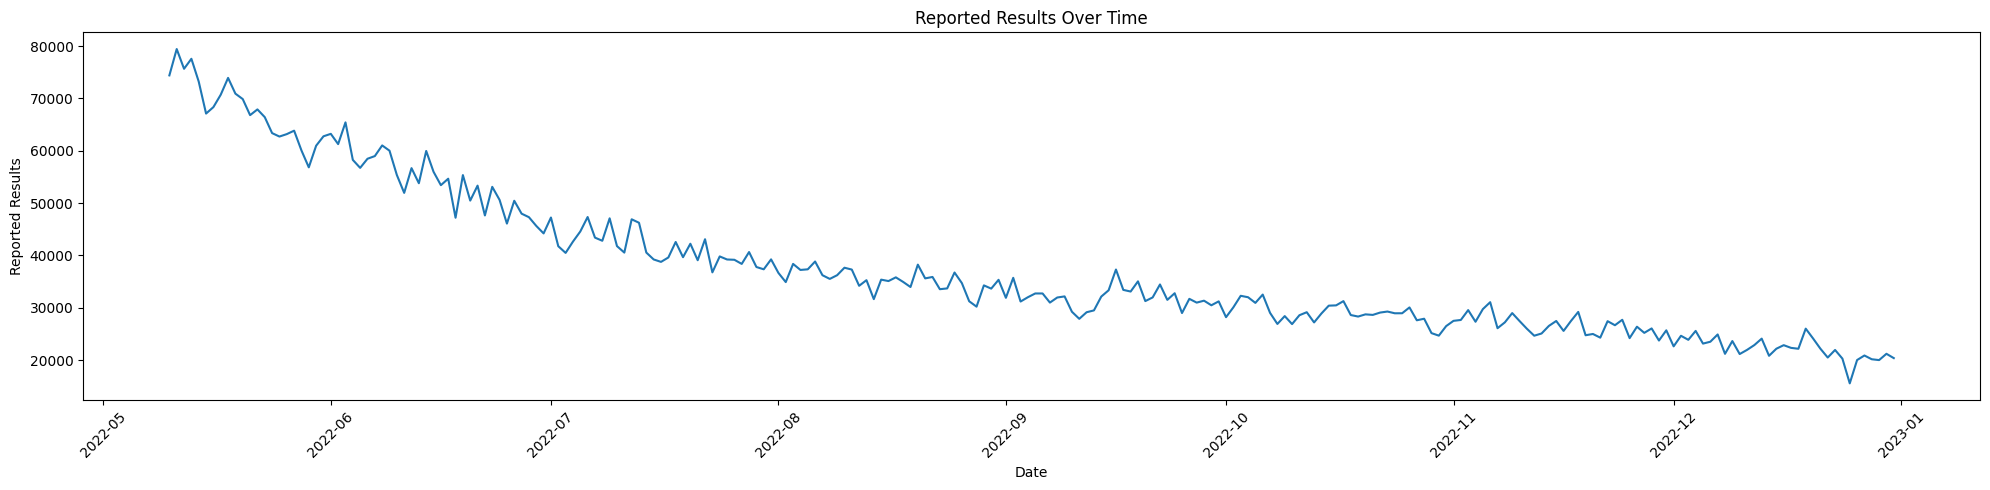

In [70]:
plot_n_players(df, date_from='2022-05-10')

In [74]:
df_filtered = df[df['date'] > '2022-05-10'].copy()
df_filtered = df_filtered.sort_values('date')

# 3. Predicting the total number of players for '2023-03-01'

In [78]:
# numeric time feature
df_filtered['date_num'] = (df_filtered['date'] - df_filtered['date'].min()).dt.days
X = df_filtered[['date_num']]
y = df_filtered['n_reported']

# split last 10% as test
split_idx = int(len(X) * 0.9)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train = df_filtered['date'].iloc[:split_idx]
dates_test = df_filtered['date'].iloc[split_idx:]


## 3.1 Linear Regression (Baseline)

In [96]:
def train(model, predict_fn, build_feats_fn, X_train, y_train, X_test, y_test):
    X_train_tansformed, y_train_transformed = build_feats_fn(X_train, y_train)
    model.fit(X_train_tansformed, y_train_transformed)

    train_pred = predict_fn(model, X_train)
    test_pred = predict_fn(model, X_test)

    # RMSE
    rmse = root_mean_squared_error(y_test, test_pred)
    print("Test RMSE:", rmse)

    # Plot results
    plt.figure(figsize=(20, 5))

    plt.plot(dates_train, y_train, label='Train Actual')
    plt.plot(dates_test, y_test, label='Test Actual')

    plt.plot(dates_train, train_pred, label='Train Trend', linewidth=2)
    plt.plot(dates_test, test_pred, label='Test Prediction', linewidth=2)

    plt.xlabel('Date')
    plt.ylabel('Reported Results')
    plt.title('Regression model with Train/Test Split')
    plt.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Test RMSE: 6343.371624941209


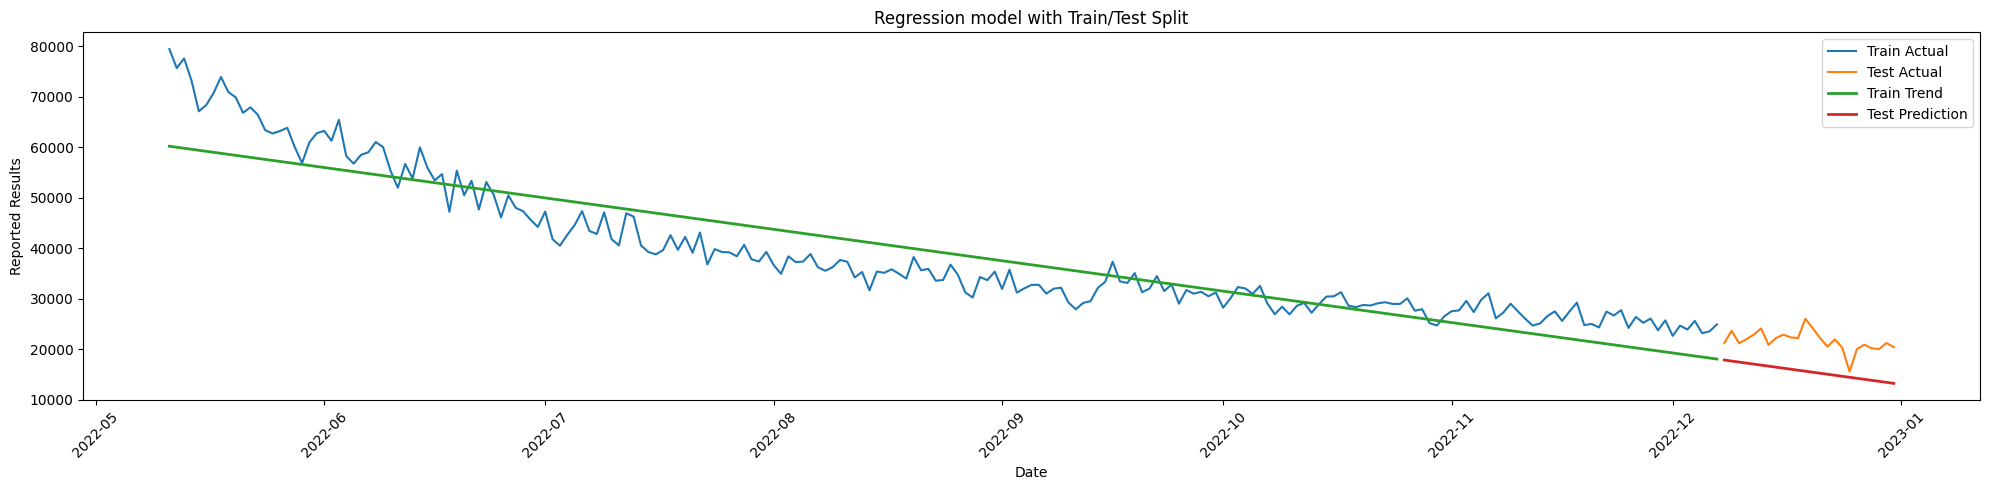

In [97]:
model = LinearRegression()

def predict_linear(model, X):
    return model.predict(X)

def build_feats_linear(X, y):
    return X, y

train(model, predict_linear, build_feats_linear, X_train, y_train, X_test, y_test)

## 3.2 Exponential Ridge Regression

Test RMSE: 1743.9312737811051


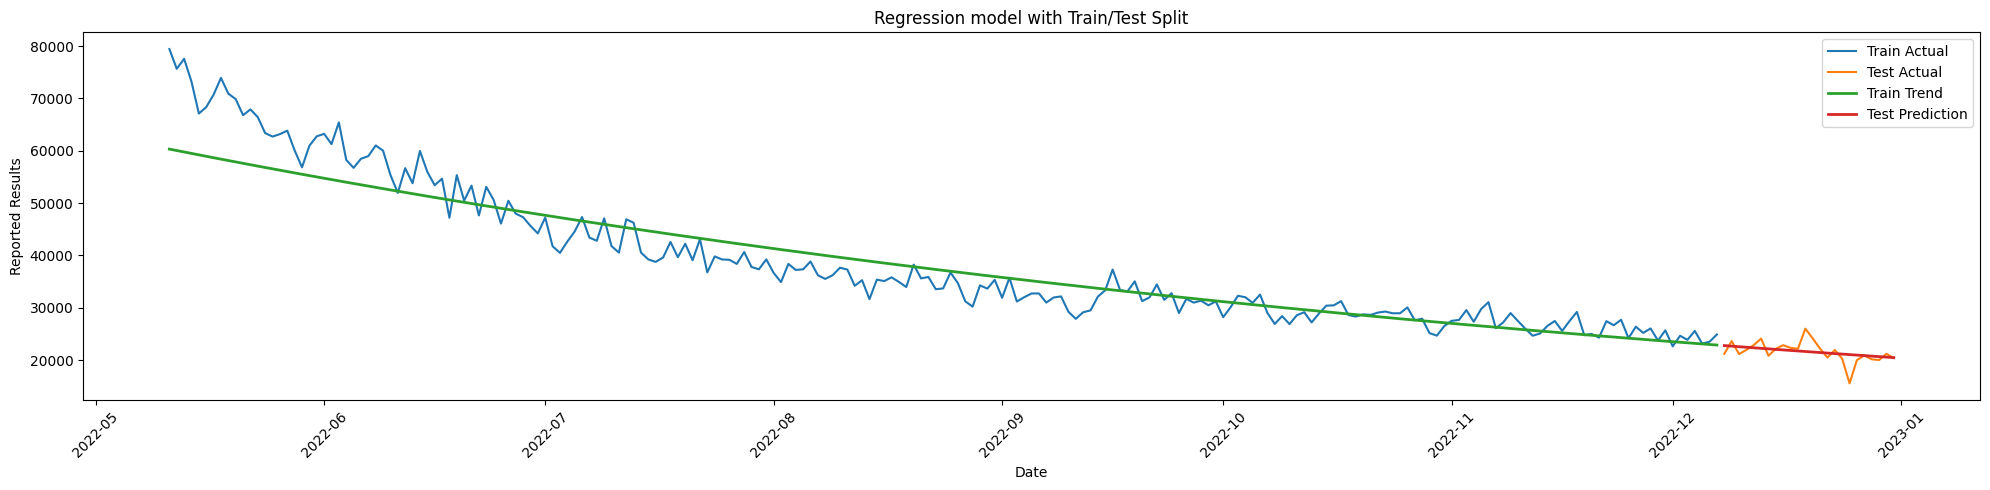

In [135]:
def predict_exp(model, X):
    return np.expm1(model.predict(X))

def build_feats_exp(X, y):
    return X, np.log1p(y)

model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=12)
)

train(model, predict_exp, build_feats_exp, X_train, y_train, X_test, y_test)

### Train on the entire dataset

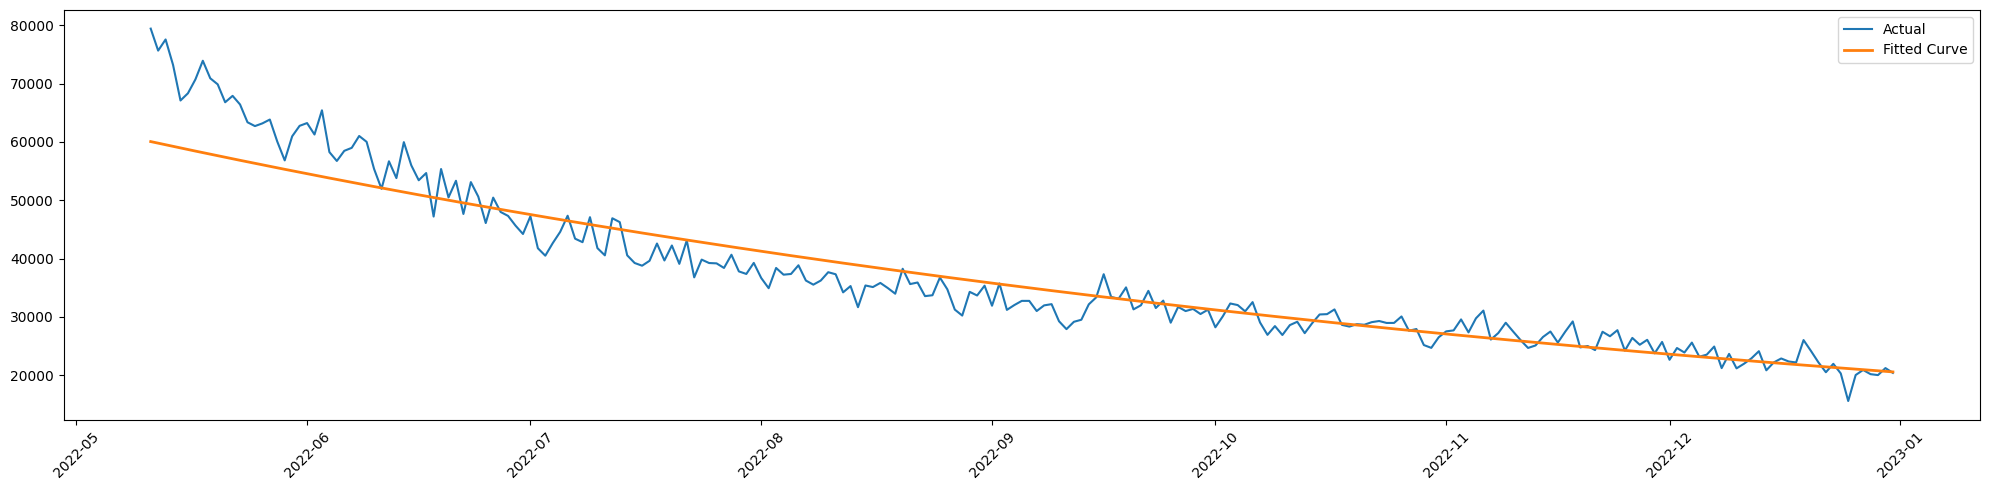

In [137]:
X_processed, y_processed = build_feats_exp(X, y)

model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=12)
)
model.fit(X_processed, y_processed)

preds = predict_exp(model, X)

# Plot
plt.figure(figsize=(20, 5))
plt.plot(df_filtered['date'], y, label='Actual')
plt.plot(df_filtered['date'], preds, label='Fitted Curve', linewidth=2)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Predict for '2023-03-01'

In [139]:
target_date = pd.to_datetime("2023-03-01")

x_target = pd.DataFrame({
    "date_num": [(target_date - df_filtered['date'].min()).days]
})


pred = predict_exp(model, x_target)

print("Prediction for 2023-01-03:", pred)

Prediction for 2023-01-03: [15606.98752195]


In [141]:
df_filtered.to_csv('data/filtered.csv')